## PCA Visualization Plot

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore', message='attempt to write a readonly database')

In [14]:

mgd = pd.read_csv("../datasets/dashboard_df.csv")
mgd.head(3)

,city,date_day,pm2_5,pm10,us_aqi,ozone,nitrogen_dioxide,sulphur_dioxide,carbon_monoxide,carbon_dioxide,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,surface_pressure,country,lat,lon
0,Chicago,2025-11-07,3.087500,3.204167,27.925942,59.166667,14.420833,5.375000,214.750000,453.541667,12.270667,56.291667,0.108333,15.035669,975.555111,US,41.8781,-87.6298
1,Chicago,2025-11-08,2.970833,3.008333,26.261498,59.958333,10.362500,2.295833,189.583333,447.000000,8.681083,70.250000,0.029167,10.070025,979.995500,US,41.8781,-87.6298
2,Chicago,2025-11-09,4.108333,4.345833,31.056741,66.916667,6.054167,1.675000,169.041667,443.333333,2.187333,73.208333,0.558333,18.010270,985.806028,US,41.8781,-87.6298


In [15]:
# Select numeric columns relevant for clustering (weather + air quality)
cluster_features = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation',
    'wind_speed_10m', 'surface_pressure',
    'pm2_5', 'pm10', 'us_aqi', 'ozone',
    'nitrogen_dioxide', 'sulphur_dioxide', 'carbon_monoxide', 'carbon_dioxide'
]

# Subset the merged dataframe
df_kms = mgd[cluster_features].copy()
df_kms.head(3)


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,surface_pressure,pm2_5,pm10,us_aqi,ozone,nitrogen_dioxide,sulphur_dioxide,carbon_monoxide,carbon_dioxide
0,12.270667,56.291667,0.108333,15.035669,975.555111,3.087500,3.204167,27.925942,59.166667,14.420833,5.375000,214.750000,453.541667
1,8.681083,70.250000,0.029167,10.070025,979.995500,2.970833,3.008333,26.261498,59.958333,10.362500,2.295833,189.583333,447.000000
2,2.187333,73.208333,0.558333,18.010270,985.806028,4.108333,4.345833,31.056741,66.916667,6.054167,1.675000,169.041667,443.333333


In [17]:
# Add these imports at the top
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def PipelineCluster():
    pipeline_base = Pipeline([
        ("scaler", StandardScaler()),
        ("PCA", PCA(n_components=5, random_state=0)),  # updated to 5 components
        ("model", KMeans(n_clusters=4, random_state=0))  # 4 clusters
    ])
    return pipeline_base

# Now this will work
PipelineCluster()

,steps,"[('scaler', ...), ('PCA', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'


In [18]:
X = df_kms.copy()
X.head(2)

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,surface_pressure,pm2_5,pm10,us_aqi,ozone,nitrogen_dioxide,sulphur_dioxide,carbon_monoxide,carbon_dioxide
0,12.270667,56.291667,0.108333,15.035669,975.555111,3.087500,3.204167,27.925942,59.166667,14.420833,5.375000,214.750000,453.541667
1,8.681083,70.250000,0.029167,10.070025,979.995500,2.970833,3.008333,26.261498,59.958333,10.362500,2.295833,189.583333,447.000000


In [19]:
# fit the Cluster pipeline to the training data (X)
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,steps,"[('scaler', ...), ('PCA', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'


In [20]:
# Create labels, column called Clusters
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(360, 14)


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,surface_pressure,pm2_5,pm10,us_aqi,ozone,nitrogen_dioxide,sulphur_dioxide,carbon_monoxide,carbon_dioxide,Clusters
0,12.270667,56.291667,0.108333,15.035669,975.555111,3.087500,3.204167,27.925942,59.166667,14.420833,5.375000,214.750000,453.541667,2
1,8.681083,70.250000,0.029167,10.070025,979.995500,2.970833,3.008333,26.261498,59.958333,10.362500,2.295833,189.583333,447.000000,2
2,2.187333,73.208333,0.558333,18.010270,985.806028,4.108333,4.345833,31.056741,66.916667,6.054167,1.675000,169.041667,443.333333,2


In [21]:
print(pipeline_cluster.steps)

[('scaler', StandardScaler()), ('PCA', PCA(n_components=5, random_state=0)), ('model', KMeans(n_clusters=4, random_state=0))]


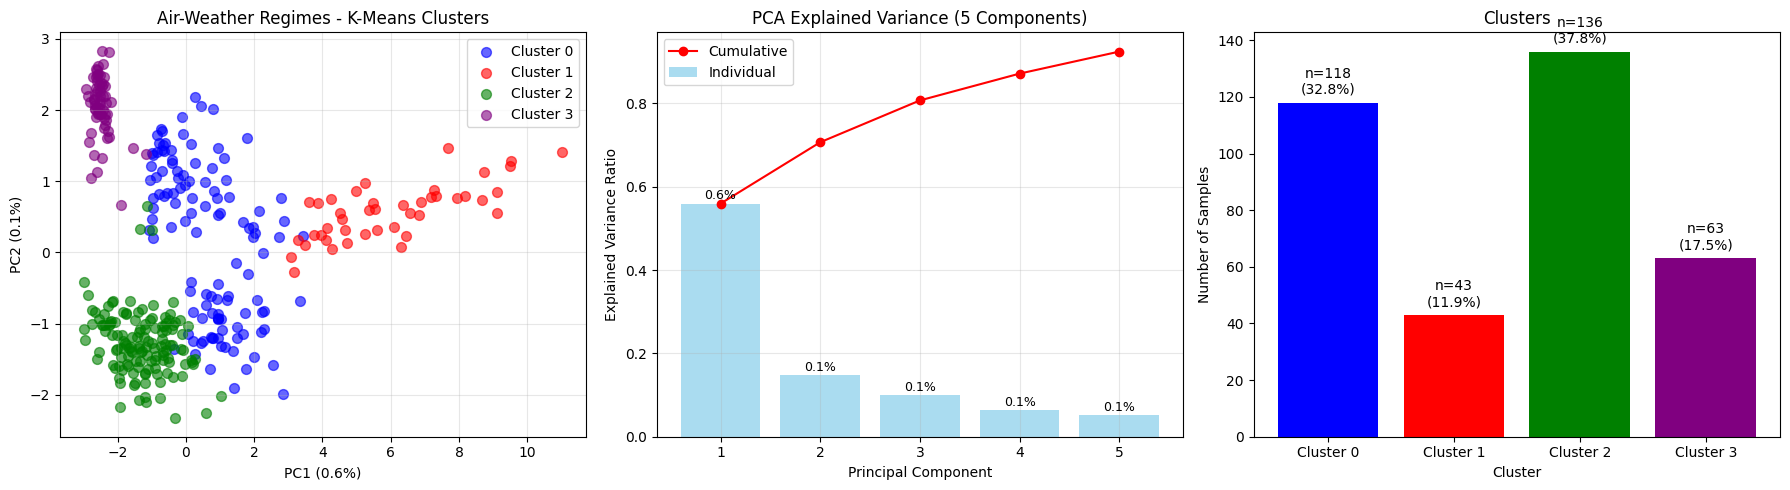

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Get PCA data
X_pca = pipeline_cluster[:-1].transform(X[feature_columns])
explained_var = pipeline_cluster['PCA'].explained_variance_ratio_

# Create figure with 3 subplots
plt.figure(figsize=(18, 5))

# ===========================================
# PLOT 1: 2D PCA with Clusters (Air-Weather Regimes)
# ===========================================
plt.subplot(1, 3, 1)

colors = ['blue', 'red', 'green', 'purple']
regime_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for cluster in range(4):
    mask = X['Clusters'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[cluster], label=regime_names[cluster], 
               alpha=0.6, s=50)

plt.xlabel(f'PC1 ({explained_var[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_var[1]:.1f}%)')
plt.title('Air-Weather Regimes - K-Means Clusters')
plt.legend()
plt.grid(True, alpha=0.3)

# ===========================================
# PLOT 2: PCA Explained Variance
# ===========================================
plt.subplot(1, 3, 2)

components = range(1, len(explained_var) + 1)
plt.bar(components, explained_var, alpha=0.7, color='skyblue', label='Individual')
plt.plot(components, np.cumsum(explained_var), 'ro-', label='Cumulative')

# Add percentage labels on bars
for i, v in enumerate(explained_var):
    plt.text(i+1, v+0.01, f'{v:.1f}%', ha='center', fontsize=9)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (5 Components)')
plt.legend()
plt.grid(True, alpha=0.3)

# ===========================================
# PLOT 3: Cluster Distribution
# ===========================================
plt.subplot(1, 3, 3)

cluster_counts = X['Clusters'].value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)

# Add count and percentage labels on bars
total = len(X)
for i, (count, bar) in enumerate(zip(cluster_counts.values, bars)):
    percentage = (count/total)*100
    plt.text(i, count+2, f'n={count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.title(f'Clusters')
plt.xticks([0, 1, 2, 3], ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

plt.tight_layout()
plt.show()